# 05a — CLV Validation: temporal holdout (doc 08)

**Phase 5, part A.** Before we trust any CLV number, we prove the BG/NBD model predicts the
**future**, not just fits the past. Method (doc 08): split the timeline at a cutoff into a
**calibration** period (fit) and a **holdout** period (test), predict each customer's holdout
purchases, and compare to what they **actually** did — repeated at **3, 6, 9-month** holdouts to
turn validation into a sensitivity analysis.

**The trap (doc 08):** moving the cutoff changes *two* things at once — calibration length AND
prediction horizon — so a 3-month holdout shows lower raw error simply because predicting 3 months
is easier. We therefore do **NOT** rank by raw MAE. We judge **calibration** (predicted vs actual by
frequency bin — hug the diagonal) and **parameter stability**, which are horizon-fair.

This is a credibility experiment (MAP fits, fast); the production CLV (05b) refits on ALL data.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import clv, utils

sns.set_theme(style="whitegrid")
PHASE = "05a_clv_validation"
HOLDOUTS = [3, 6, 9]   # months (doc 08)

In [2]:
tx = pd.read_parquet(utils.DATA_PROCESSED / "clean_transactions.parquet")
print("transactions:", tx.shape, "| dates", tx["InvoiceDate"].min().date(), "->", tx["InvoiceDate"].max().date())

transactions: (790704, 9) | dates 2009-12-01 -> 2011-12-09


## Run the 3/6/9-month backtests

`clv.evaluate_cutoff(months)` splits the data, fits BG/NBD on the calibration period, predicts the
holdout, and returns the per-customer table + fitted parameters.

In [3]:
results = {m: clv.evaluate_cutoff(tx, months=m) for m in HOLDOUTS}
for m, r in results.items():
    print(f"{m}-mo holdout: train_end={r['train_end'].date()} | n={r['n_customers']:,} | "
          f"holdout_days={r['holdout_days']} | total predicted={r['total_predicted']:,.0f} vs "
          f"actual={r['total_actual']:,.0f}  (ratio {r['total_predicted']/r['total_actual']:.3f})")

Output()

Output()

Output()

3-mo holdout: train_end=2011-09-09 | n=5,253 | holdout_days=91 | total predicted=3,783 vs actual=4,931  (ratio 0.767)
6-mo holdout: train_end=2011-06-09 | n=4,941 | holdout_days=183 | total predicted=7,583 vs actual=7,781  (ratio 0.975)
9-mo holdout: train_end=2011-03-09 | n=4,559 | holdout_days=275 | total predicted=11,549 vs actual=10,312  (ratio 1.120)


## Calibration small-multiples — predicted vs actual by calibration frequency

The headline visual: within each calibration-frequency bin, the model's mean predicted holdout
purchases should track the actual mean. Lines that overlap = a well-calibrated model.

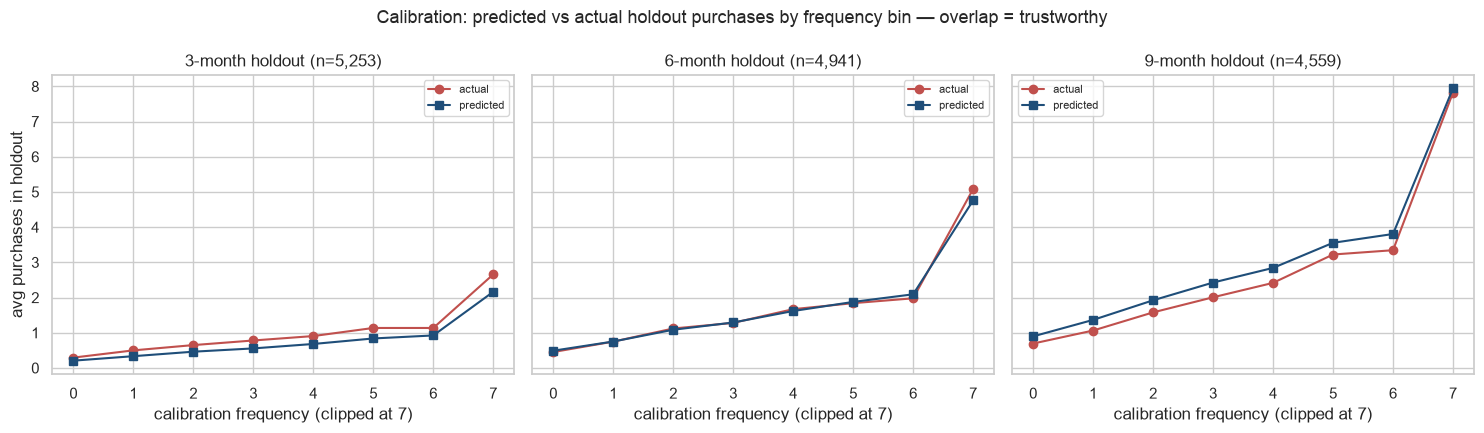

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
for ax, m in zip(axes, HOLDOUTS):
    cal = clv.calibration_by_frequency(results[m]["split"])
    ax.plot(cal.index, cal["actual"], marker="o", color="#c0504d", label="actual")
    ax.plot(cal.index, cal["predicted"], marker="s", color="#1f4e79", label="predicted")
    ax.set_title(f"{m}-month holdout (n={results[m]['n_customers']:,})")
    ax.set_xlabel("calibration frequency (clipped at 7)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("avg purchases in holdout")
fig.suptitle("Calibration: predicted vs actual holdout purchases by frequency bin — overlap = trustworthy",
             fontsize=13)
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "calibration_small_multiples.png"), dpi=150, bbox_inches="tight")
plt.show()

**Reading the calibration — shape excellent, a seasonal vertical shift.** In all three holdouts the
predicted curve TRACKS the actual's rise with frequency, so the model correctly **orders** customers
by future purchases (what matters for targeting). But the whole curve shifts vertically: **3-mo
under-predicts (×0.77), 6-mo is near-perfect (×0.98), 9-mo over-predicts (×1.12)**. A uniform shift
(not bin-by-bin) points to a TIME effect, not a structural flaw — and the cause is **seasonality**:
this is gift-ware with a strong Christmas peak, but BG/NBD assumes a constant Poisson rate (no
seasonality, doc 15). The 3-month holdout (Sep→Dec) is the Christmas run-up, so actuals spike above
the flat prediction (under-prediction); the 6-month window (summer lull + peak) balances out.
**Reassuringly our deliverable is a 12-month CLV** — a full seasonal cycle — so the seasonality
largely averages out, and the near-perfect 6-month fit (which contains the peak) supports trusting it.

## Parameter stability across cutoffs

If the four fitted parameters (r, α, a, b) stay stable as the cutoff moves, the model is robust;
big swings would mean a fragile fit. This is far more horizon-fair than raw error.

                    r   alpha      a      b
holdout_months                             
3               0.612  58.744  0.171  2.561
6               0.644  60.701  0.148  2.871
9               0.686  62.591  0.116  3.607


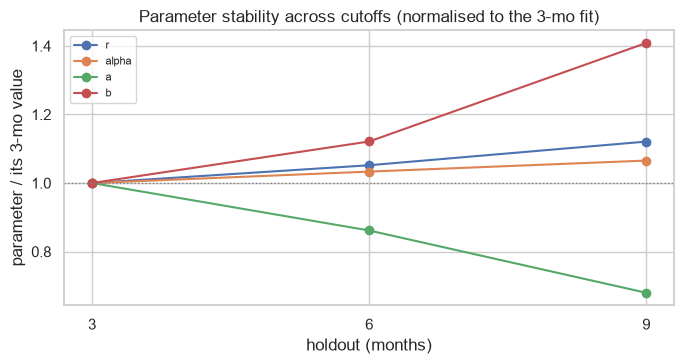

In [5]:
params = pd.DataFrame({m: results[m]["params"] for m in HOLDOUTS}).T
params.index.name = "holdout_months"
print(params.round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 3.8))
for p in ["r", "alpha", "a", "b"]:
    ax.plot(params.index, params[p] / params[p].iloc[0], marker="o", label=p)
ax.axhline(1.0, color="grey", ls=":", lw=1)
ax.set_xlabel("holdout (months)"); ax.set_ylabel("parameter / its 3-mo value")
ax.set_title("Parameter stability across cutoffs (normalised to the 3-mo fit)")
ax.set_xticks(HOLDOUTS); ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "parameter_stability.png"), dpi=150, bbox_inches="tight")
plt.show()

**Stability:** r and α (the buying process) are stable (~10% drift). a and b (the dropout process)
drift more but SMOOTHLY and monotonically with calibration length — longer history softens the
dropout estimate (mean dropout ≈ 6.3% → 3.1%) — a systematic relationship, not erratic fragility.

## Aggregate accuracy (read honestly — NOT a ranking)

Total predicted vs actual purchases, and per-customer MAE. We report MAE for completeness but do
NOT declare a "winner": shorter horizons are mechanically easier, so a lower 3-month MAE proves
nothing about model quality (doc 08). The interesting result is graceful decay + calibration.

In [6]:
agg = pd.DataFrame({
    "total_predicted": {m: results[m]["total_predicted"] for m in HOLDOUTS},
    "total_actual": {m: results[m]["total_actual"] for m in HOLDOUTS},
    "pred/actual": {m: results[m]["total_predicted"] / results[m]["total_actual"] for m in HOLDOUTS},
    "MAE_per_customer": {m: results[m]["mae"] for m in HOLDOUTS},
})
agg.index.name = "holdout_months"
print(agg.round(3).to_string())

                total_predicted  total_actual  pred/actual  MAE_per_customer
holdout_months                                                              
3                      3783.055        4931.0        0.767             0.694
6                      7583.317        7781.0        0.975             1.040
9                     11548.581       10312.0        1.120             1.523


---
**Verdict — trustworthy for its job, with one honest limitation.** The model's customer **ranking**
is well-calibrated (predicted tracks actual's shape across all cutoffs), and it is near-perfectly
calibrated over the 6-month window (×0.98). Its one assumption violation is **no seasonality** —
visible as a vertical bias on short holdouts ending at Christmas (3-mo ×0.77). Because the production
CLV uses a **12-month horizon (a full seasonal cycle)**, that bias largely averages out, so the
forecast is fit for purpose — especially for *ranking* customers, which is what feeds Phase 6. The
model has earned the right to be refit on FULL history. **Next:** `05b_clv_production` — refit with
**MCMC** (credible intervals + posterior predictive checks) and save `clv_predictions.parquet`.